In [1]:
#загрузка библиотек
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as statf
import statsmodels.stats.diagnostic as dg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.sandwich_covariance import cov_cluster_2groups
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
dta = pd.read_parquet("lag_model_monthly_dyads_giga_r20_50k_100k.parquet")
dta

,dyad_id,channel_i,channel_j,month,month_id,tie_strength,tie_signed,tie_congruence,tie_conflict,posts_i,...,negative_share_i,negative_share_j,negative_share_mean,n_topics_i,n_topics_j,n_common_topics,tie_strength_lag1,tie_signed_lag1,tie_congruence_lag1,tie_conflict_lag1
0,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-02,2,0.028814,-0.022034,0.028814,0.050847,110,...,0.445455,0.344828,0.395141,9,4,3,0.045455,0.007576,0.045455,0.037879
1,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-03,3,0.059701,0.050616,0.059701,0.009085,122,...,0.475410,0.187500,0.331455,9,5,4,0.028814,-0.022034,0.028814,0.050847
2,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-04,4,0.049100,0.027823,0.049100,0.021277,107,...,0.439252,0.416667,0.427960,11,5,5,0.059701,0.050616,0.059701,0.009085
3,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-05,5,0.055652,0.008116,0.055652,0.047536,126,...,0.476190,0.371429,0.423810,10,6,6,0.049100,0.027823,0.049100,0.021277
4,@ASGasparyan___@AptiAlaudinovAKHMAT,@ASGasparyan,@AptiAlaudinovAKHMAT,2024-06,6,0.042915,0.006478,0.042915,0.036437,128,...,0.500000,0.571429,0.535714,9,4,4,0.055652,0.008116,0.055652,0.047536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118795,@vvgladkov___@vysokygovorit,@vvgladkov,@vysokygovorit,2025-09,21,0.087500,0.027778,0.087500,0.059722,50,...,0.580000,0.520000,0.550000,6,4,3,0.083333,0.047917,0.083333,0.035417
118796,@vvgladkov___@vysokygovorit,@vvgladkov,@vysokygovorit,2025-10,22,0.045455,-0.032468,0.045455,0.077922,37,...,0.540541,0.586207,0.563374,6,6,3,0.087500,0.027778,0.087500,0.059722
118797,@vvgladkov___@vysokygovorit,@vvgladkov,@vysokygovorit,2025-11,23,0.123967,0.070248,0.123967,0.053719,29,...,0.517241,0.444444,0.480843,3,3,1,0.045455,-0.032468,0.045455,0.077922
118798,@vvgladkov___@vysokygovorit,@vvgladkov,@vysokygovorit,2025-12,24,0.046154,0.011538,0.046154,0.034615,27,...,0.407407,0.476190,0.441799,5,6,2,0.123967,0.070248,0.123967,0.053719


In [3]:
#посмотрим, что все верно загрузилось
print("число каналов:", len(set(dta["channel_i"]) | set(dta["channel_j"])))
print("число диад:", dta["dyad_id"].nunique())
print("число месяцев:", dta["month"].nunique())
print("период:", dta["month"].min(), "-", dta["month"].max())

display(dta.isna().mean().sort_values(ascending=False).head(10))

число каналов: 100
число диад: 4950
число месяцев: 24
период: 2024-02 - 2026-01


dyad_id                0.0
channel_i              0.0
tie_congruence_lag1    0.0
tie_signed_lag1        0.0
tie_strength_lag1      0.0
n_common_topics        0.0
n_topics_j             0.0
n_topics_i             0.0
negative_share_mean    0.0
negative_share_j       0.0
dtype: float64

In [4]:
#добавим fe на кварталы
dta = dta.copy()
dta["month_date"] = pd.to_datetime(dta["month"].astype(str) + "-01")
dta["quarter"] = dta["month_date"].dt.to_period("Q").astype(str)

dta["channel_i_code"] = pd.Categorical(dta["channel_i"]).codes
dta["channel_j_code"] = pd.Categorical(dta["channel_j"]).codes

display(dta[["month", "quarter"]].drop_duplicates().sort_values("month"))

,month,quarter
0,2024-02,2024Q1
1,2024-03,2024Q1
2,2024-04,2024Q2
3,2024-05,2024Q2
4,2024-06,2024Q2
5,2024-07,2024Q3
6,2024-08,2024Q3
7,2024-09,2024Q3
8,2024-10,2024Q4
9,2024-11,2024Q4


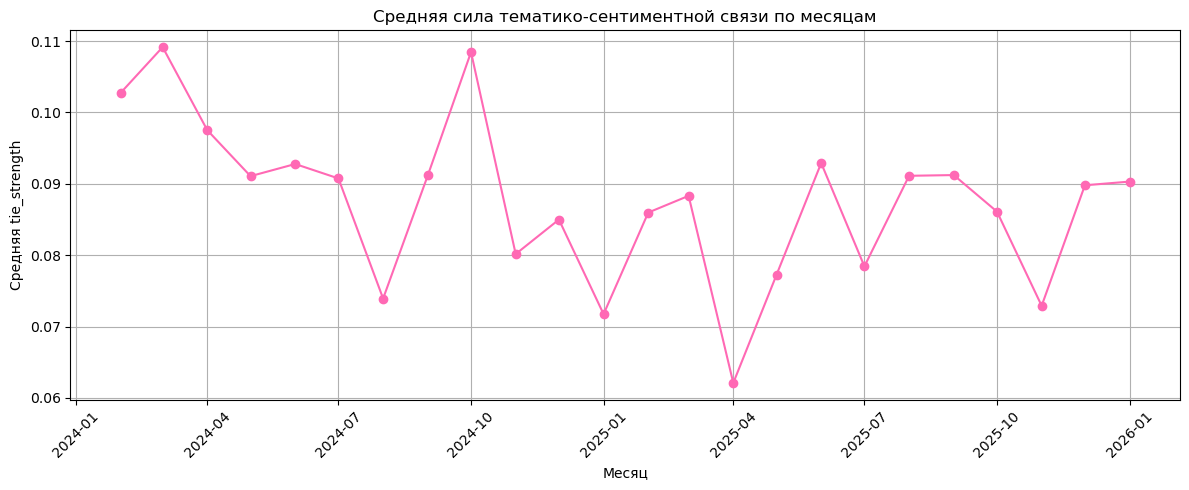

In [5]:
#визуализируем динамику зависимой переменной
monthly_diag = (dta.groupby("month", observed=True).agg(
        n_dyads=("dyad_id", "size"),
        tie_strength_mean=("tie_strength", "mean"),
        tie_strength_sd=("tie_strength", "std"),
        tie_strength_lag1_mean=("tie_strength_lag1", "mean"),
        posts_sum_mean=("posts_sum", "mean"),).reset_index())
monthly_diag["month_date"] = pd.to_datetime(monthly_diag["month"].astype(str) + "-01")

plt.figure(figsize=(12, 5))
plt.plot(monthly_diag["month_date"], monthly_diag["tie_strength_mean"], marker="o", c='hotpink')
plt.title("Средняя сила тематико-сентиментной связи по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средняя tie_strength")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
#для более детальной визуализации посчитаем месячную корреляцию текущей и лагированной связи
monthly_corr = (dta.dropna(subset=["tie_strength", "tie_strength_lag1"]).groupby("month", observed=True).apply(lambda x: x["tie_strength"].corr(x["tie_strength_lag1"]))
    .reset_index(name="corr_tie_strength_lag1"))

monthly_corr["month_date"] = pd.to_datetime(monthly_corr["month"].astype(str) + "-01")

C:\Users\sonya\AppData\Local\Temp\ipykernel_13756\2100939511.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_corr = (dta.dropna(subset=["tie_strength", "tie_strength_lag1"]).groupby("month", observed=True).apply(lambda x: x["tie_strength"].corr(x["tie_strength_lag1"]))


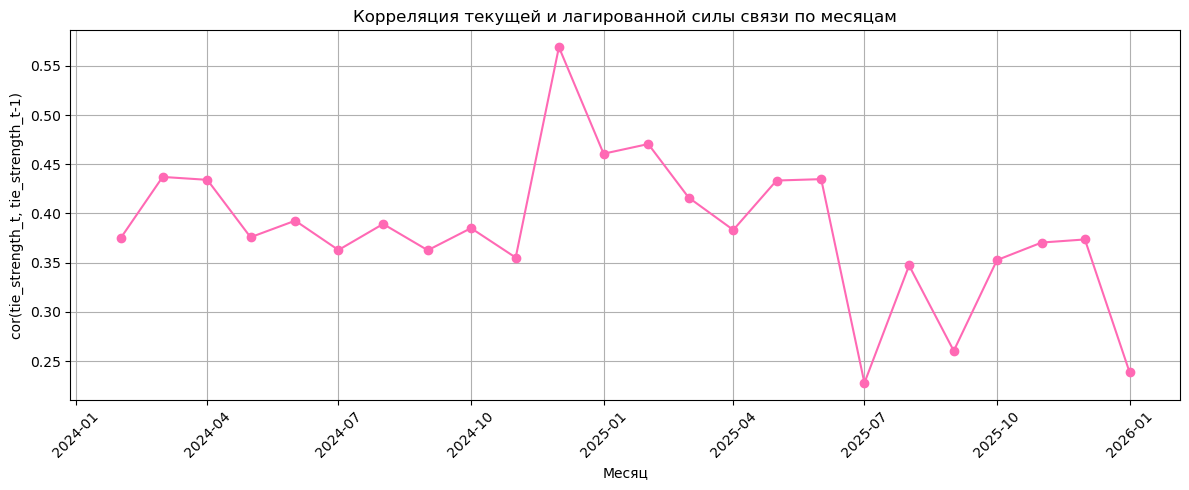

In [7]:
#визуализируем месячную корреляцию текущей и лагированной связи
plt.figure(figsize=(12, 5))
plt.plot(monthly_corr["month_date"], monthly_corr["corr_tie_strength_lag1"], marker="o", c='hotpink')
plt.title("Корреляция текущей и лагированной силы связи по месяцам")
plt.xlabel("Месяц")
plt.ylabel("cor(tie_strength_t, tie_strength_t-1)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Можно сказать, что между силой связи диад в текущем и предыдущем месяце наблюдается устойчивая положительная корреляция. Это свидетельствует о том, что тематико-сентиментная структура сети обладает определенной инерцией: пары каналов, близкие друг к другу в одном месяце, как правило, остаются относительно близкими и в следующем. При этлом  величина корреляции  варьируется во времени, это указывает на наличие периодов большей и меньшей устойчивости сети.

C:\Users\sonya\AppData\Local\Temp\ipykernel_13756\716197903.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=False)


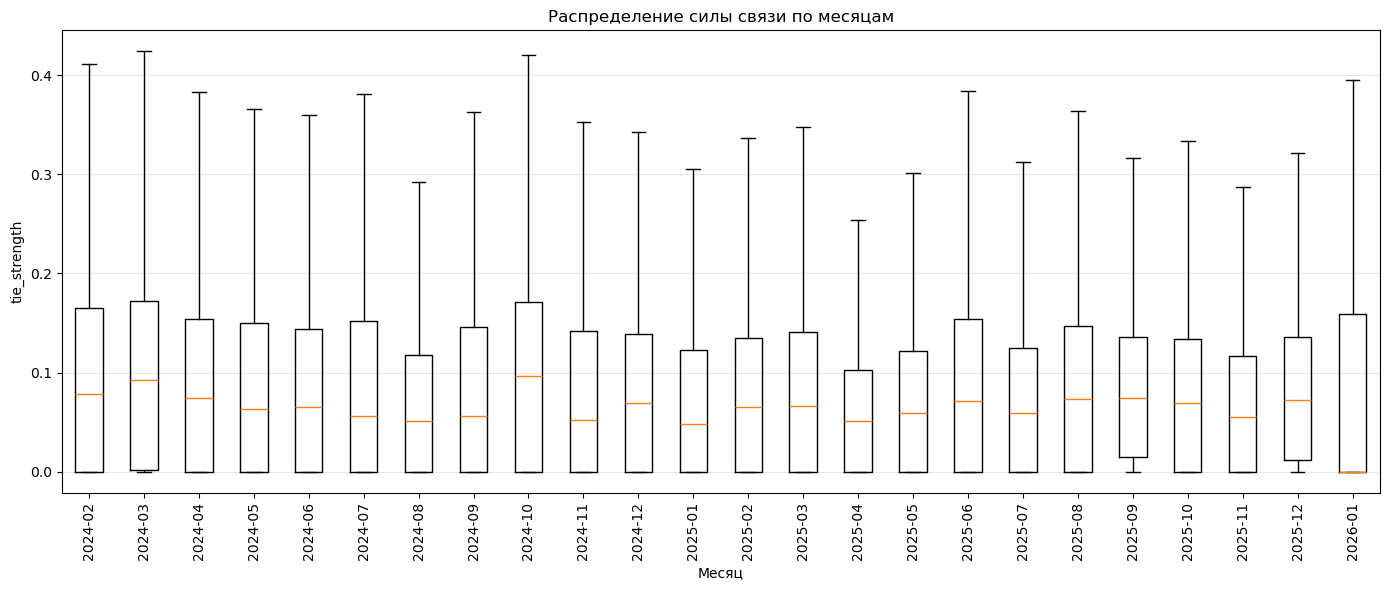

In [8]:
#распределение зависимой переменной по месяцам
months = sorted(dta["month"].unique())
box_data = [dta.loc[dta["month"] == m, "tie_strength"] for m in months]

plt.figure(figsize=(14, 6))
plt.boxplot(box_data, labels=months, showfliers=False)
plt.title("Распределение силы связи по месяцам")
plt.xlabel("Месяц")
plt.ylabel("tie_strength")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

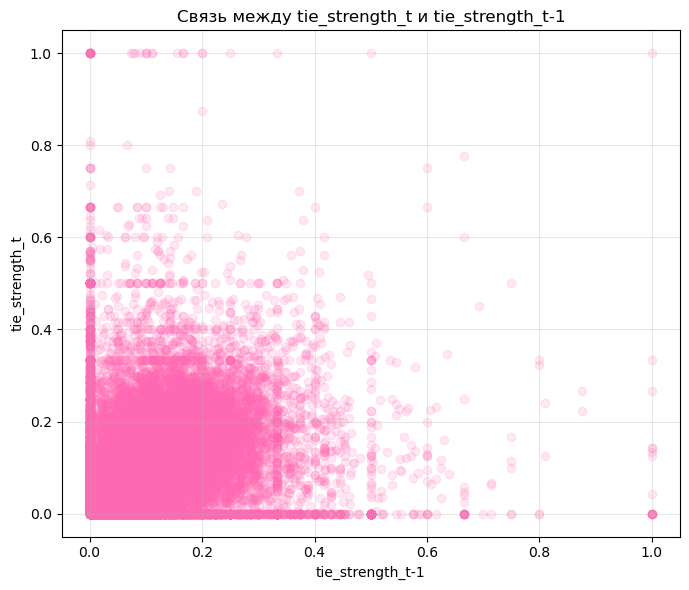

In [9]:
#scatter plot текущего и прошлого значения
plot_sample = dta.sample(min(40000, len(dta)), random_state=42)

plt.figure(figsize=(7, 6))
plt.scatter(plot_sample["tie_strength_lag1"], plot_sample["tie_strength"], alpha=0.15, color='hotpink')
plt.title("Связь между tie_strength_t и tie_strength_t-1")
plt.xlabel("tie_strength_t-1")
plt.ylabel("tie_strength_t")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
#стационарность месячного среднего
adf_data = monthly_diag["tie_strength_mean"].dropna()
result = adfuller(adf_data)

print("Statistic:", result[0])
print("p-value:", result[1])

Statistic: -3.8409281765624455
p-value: 0.002515255418622403


Данные стационарные, дополнительные преобразования временного ряда не требуются.

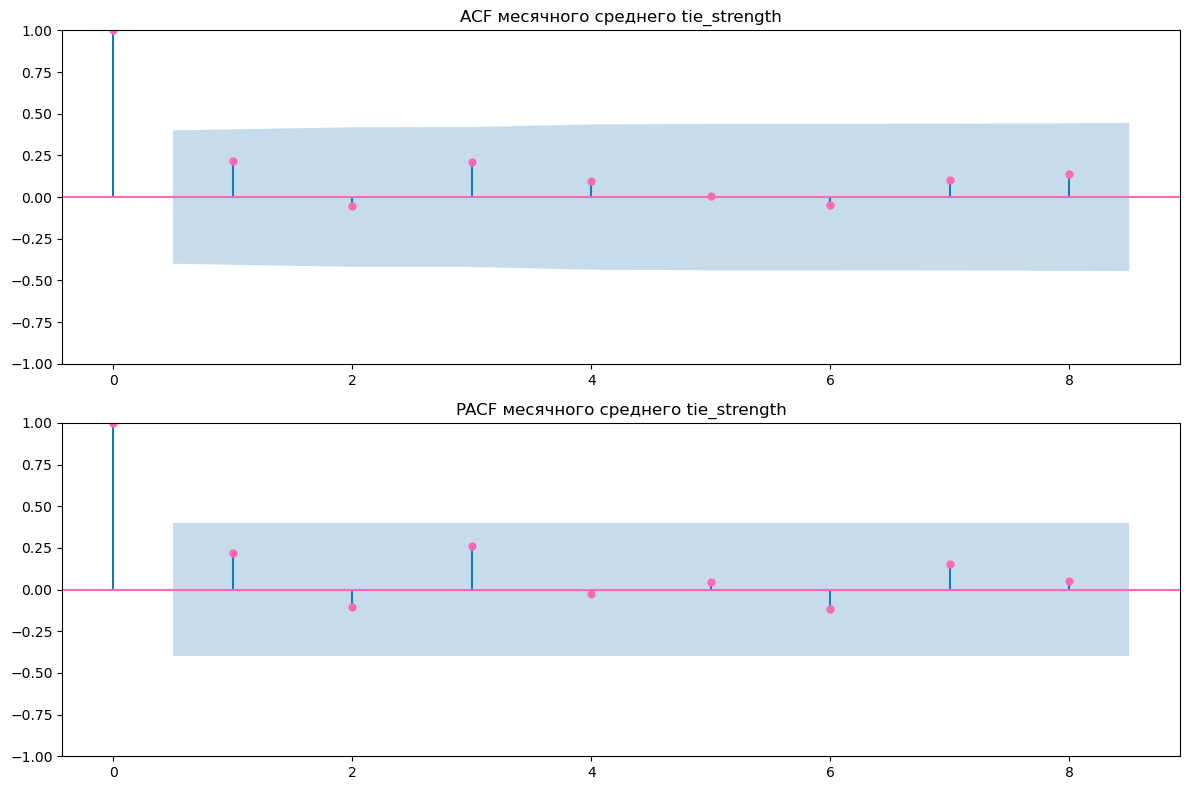

In [11]:
#acf и pacf месячного среднего
max_lags = min(8, len(monthly_diag) // 2 - 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(monthly_diag["tie_strength_mean"], lags=max_lags, ax=ax1, color='hotpink')
ax1.set_title("ACF месячного среднего tie_strength")

plot_pacf(monthly_diag["tie_strength_mean"], lags=max_lags, ax=ax2, method="ywm", color='hotpink')
ax2.set_title("PACF месячного среднего tie_strength")

plt.tight_layout()
plt.show()

ACF и PACF для месячного среднего значения tie_strength не показывают выраженной автокорреляции агрегированного ряда. Но это не противоречит использованию лагированной модели, поскольку основная гипотеза проверяется на уровне диад, а не на уровне месячного среднего.

In [12]:
#тест бреуша-годфри для агрегированного ряда
monthly_diag = monthly_diag.sort_values("month").copy()
monthly_diag["tie_strength_mean_lag1"] = monthly_diag["tie_strength_mean"].shift(1)

bg_base = monthly_diag.dropna(subset=["tie_strength_mean", "tie_strength_mean_lag1"])
bg_model = statf.ols("tie_strength_mean ~ tie_strength_mean_lag1", data=bg_base).fit()

bg_result = dg.acorr_breusch_godfrey(bg_model, nlags=min(3, len(bg_base) // 3))

print("LM statistic:", bg_result[0])
print("LM p-value:", bg_result[1])
print("F statistic:", bg_result[2])
print("F p-value:", bg_result[3])

LM statistic: 6.397339845667215
LM p-value: 0.09380028892906538
F statistic: 2.3119210245345068
F p-value: 0.11056176472769046


In [13]:
#функции для моделей с кластеризацией по двум каналам
def fit_ols_cluster2(formula, data):
    model = statf.ols(formula, data=data).fit()
    clustered_model = model.get_robustcov_results(
        cov_type="cluster",
        groups=data[["channel_i_code", "channel_j_code"]].to_numpy())
    return model, clustered_model

#функция для таблицы коэффициентов
def coef_table(model, model_name):
    out = pd.DataFrame({
        "model": model_name,
        "term": model.model.exog_names,
        "coef": model.params,
        "se": model.bse,
        "t": model.tvalues,
        "p_value": model.pvalues})

    out["stars"] = np.select(
        [out["p_value"] < 0.001, out["p_value"] < 0.01, out["p_value"] < 0.05, out["p_value"] < 0.1],
        ["***", "**", "*", "."], default="")

    return out

def model_info(model, model_name):
    return pd.DataFrame({
        "model": [model_name],
        "nobs": [int(model.nobs)],
        "r2": [model.rsquared],
        "aic": [model.aic],
        "bic": [model.bic]})

In [14]:
#кодируем каналы для двухуровневой кластеризации
dta["channel_i_code"] = dta["channel_i"].astype("category").cat.codes
dta["channel_j_code"] = dta["channel_j"].astype("category").cat.codes

In [15]:
#модель 1: базовая спецификация с лагом
formula_m1 = "tie_strength ~ tie_strength_lag1"

m1, cov_m1 = fit_ols_cluster2(formula_m1, dta)
print(cov_m1.summary())

                            OLS Regression Results                            
Dep. Variable:           tie_strength   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     97.56
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.24e-16
Time:                        19:05:43   Log-Likelihood:             1.1368e+05
No. Observations:              118800   AIC:                        -2.274e+05
Df Residuals:                  118798   BIC:                        -2.273e+05
Df Model:                           1                                         
Covariance Type:              cluster                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0545      0.00

In [16]:
#модель 2: лаговая спецификация с квартальными fe
formula_m2 = "tie_strength ~ tie_strength_lag1 + C(quarter)"

m2, cov_m2 = fit_ols_cluster2(formula_m2, dta)
print(cov_m2.summary())

                            OLS Regression Results                            
Dep. Variable:           tie_strength   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     21.05
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.53e-19
Time:                        19:05:44   Log-Likelihood:             1.1394e+05
No. Observations:              118800   AIC:                        -2.279e+05
Df Residuals:                  118790   BIC:                        -2.278e+05
Df Model:                           9                                         
Covariance Type:              cluster                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0734 

In [17]:
#модель 3: лаговая спецификация с контролями и квартальными fe
formula_m3 = "tie_strength ~ tie_strength_lag1 + posts_sum + posts_diff + topic_diversity_mean + negative_share_mean + n_common_topics + C(quarter)"

m3, cov_m3 = fit_ols_cluster2(formula_m3, dta)
print(cov_m3.summary())

                            OLS Regression Results                            
Dep. Variable:           tie_strength   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     66.57
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.41e-43
Time:                        19:05:46   Log-Likelihood:             1.2354e+05
No. Observations:              118800   AIC:                        -2.470e+05
Df Residuals:                  118785   BIC:                        -2.469e+05
Df Model:                          14                                         
Covariance Type:              cluster                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0471 

In [18]:
#проверяем корреляции между предикторами
vif_vars = [
    "tie_strength_lag1",
    "posts_sum",
    "posts_diff",
    "topic_diversity_mean",
    "negative_share_mean",
    "n_common_topics"
]

dta[vif_vars].corr()

,tie_strength_lag1,posts_sum,posts_diff,topic_diversity_mean,negative_share_mean,n_common_topics
tie_strength_lag1,1.000000,0.081915,0.036494,0.124546,0.259998,0.203614
posts_sum,0.081915,1.000000,0.953589,0.332995,0.006536,0.482733
posts_diff,0.036494,0.953589,1.000000,0.211781,-0.025773,0.291874
topic_diversity_mean,0.124546,0.332995,0.211781,1.000000,0.153039,0.737912
negative_share_mean,0.259998,0.006536,-0.025773,0.153039,1.000000,0.163903
n_common_topics,0.203614,0.482733,0.291874,0.737912,0.163903,1.000000


In [19]:
#считаем vif для предикторов
vif_data = dta[vif_vars].dropna().copy()
vif_data = sm.add_constant(vif_data)

vif_table = pd.DataFrame({"variable": vif_data.columns, "vif": [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]})
vif_table.loc[vif_table["variable"] != "const"].sort_values("vif", ascending=False)

,variable,vif
2,posts_sum,22.696340
3,posts_diff,18.986824
6,n_common_topics,3.849585
4,topic_diversity_mean,2.248850
1,tie_strength_lag1,1.107543
5,negative_share_mean,1.098456


Дополнительно проверили на мультиколлинеарность, оказалось, что posts_sum и posts_diff  сильно связаны между собой. Значит, обе переменные во многом описывают один и тот же аспект активности пары каналов. Поэтому дополнительно оценим компактную спецификацию без posts_diff.

In [20]:
#модель 3b: спецификация без posts_diff
formula_m3b = "tie_strength ~ tie_strength_lag1 + posts_sum + topic_diversity_mean + negative_share_mean + n_common_topics + C(quarter)"

m3b, cov_m3b = fit_ols_cluster2(formula_m3b, dta)
print(cov_m3b.summary())

                            OLS Regression Results                            
Dep. Variable:           tie_strength   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     56.40
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.59e-39
Time:                        19:05:47   Log-Likelihood:             1.2349e+05
No. Observations:              118800   AIC:                        -2.470e+05
Df Residuals:                  118786   BIC:                        -2.468e+05
Df Model:                          13                                         
Covariance Type:              cluster                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0464 

In [21]:
#проверим vif для спецификации без posts_diff
vif_vars_3b = ["tie_strength_lag1", "posts_sum", "topic_diversity_mean", "negative_share_mean", "n_common_topics"]
vif_data_3b = dta[vif_vars_3b].dropna().copy()
vif_data_3b = sm.add_constant(vif_data_3b)

vif_table_3b = pd.DataFrame({"variable": vif_data_3b.columns, "vif": [variance_inflation_factor(vif_data_3b.values, i) for i in range(vif_data_3b.shape[1])]})
vif_table_3b.loc[vif_table_3b["variable"] != "const"].sort_values("vif", ascending=False)

,variable,vif
5,n_common_topics,2.629015
3,topic_diversity_mean,2.209244
2,posts_sum,1.314753
1,tie_strength_lag1,1.107002
4,negative_share_mean,1.098255


После исключения posts_diff мультиколлинеарность снизилась: VIF для posts_sum стал низким, проблемными остались только topic_diversity_mean и n_common_topics, но их значения умеренно высокие. При этом основной коэффициент tie_strength_lag1 почти не изменился, тоесть вывод об устойчивости тематико-сентиментных связей не зависит от удаления posts_diff.

Поэтому выбираем 3b в качестве финальгной модели. Она включает лаг зависимой переменной, квартальные фиксированные эффекты и основные контрольные переменные, но исключает posts_diff, чтобы минимизировать проблему мультиколлинеарности.

In [22]:
#выведем основные коэффициенты
model_tables = pd.concat([
    coef_table(cov_m1, "m1_base"),
    coef_table(cov_m2, "m2_quarter_fe"),
    coef_table(cov_m3, "m3_controls_quarter_fe"),
    coef_table(cov_m3b, "m3b_final")], ignore_index=True)

model_infos = pd.concat([
    model_info(m1, "m1_base"),
    model_info(m2, "m2_quarter_fe"),
    model_info(m3, "m3_controls_quarter_fe"),
    model_info(m3b, "m3b_final")], ignore_index=True)

main_terms = [
    "Intercept",
    "tie_strength_lag1",
    "posts_sum",
    "posts_diff",
    "topic_diversity_mean",
    "negative_share_mean",
    "n_common_topics"]

main_results = model_tables.loc[model_tables["term"].isin(main_terms)].copy()

display(main_results)
display(model_infos)

,model,term,coef,se,t,p_value,stars
0,m1_base,Intercept,0.054514,0.005056,10.781543,2.455765e-18,***
1,m1_base,tie_strength_lag1,0.381188,0.038593,9.877176,2.236002e-16,***
2,m2_quarter_fe,Intercept,0.073407,0.007692,9.543810,1.183663e-15,***
11,m2_quarter_fe,tie_strength_lag1,0.379699,0.039169,9.693734,5.594151e-16,***
12,m3_controls_quarter_fe,Intercept,0.047070,0.009103,5.170891,1.233330e-06,***
21,m3_controls_quarter_fe,tie_strength_lag1,0.271177,0.034738,7.806449,6.549648e-12,***
22,m3_controls_quarter_fe,posts_sum,-0.000100,0.000064,-1.549575,1.244669e-01,
23,m3_controls_quarter_fe,posts_diff,0.000093,0.000064,1.446686,1.511759e-01,
24,m3_controls_quarter_fe,topic_diversity_mean,-0.222428,0.025771,-8.630984,1.122464e-13,***
25,m3_controls_quarter_fe,negative_share_mean,0.156543,0.015932,9.825721,2.891855e-16,***


,model,nobs,r2,aic,bic
0,m1_base,118800,0.136672,-227359.793676,-227340.423282
1,m2_quarter_fe,118800,0.140452,-227865.137645,-227768.285678
2,m3_controls_quarter_fe,118800,0.268658,-247044.251193,-246898.973243
3,m3b_final,118800,0.268109,-246957.185950,-246821.593196


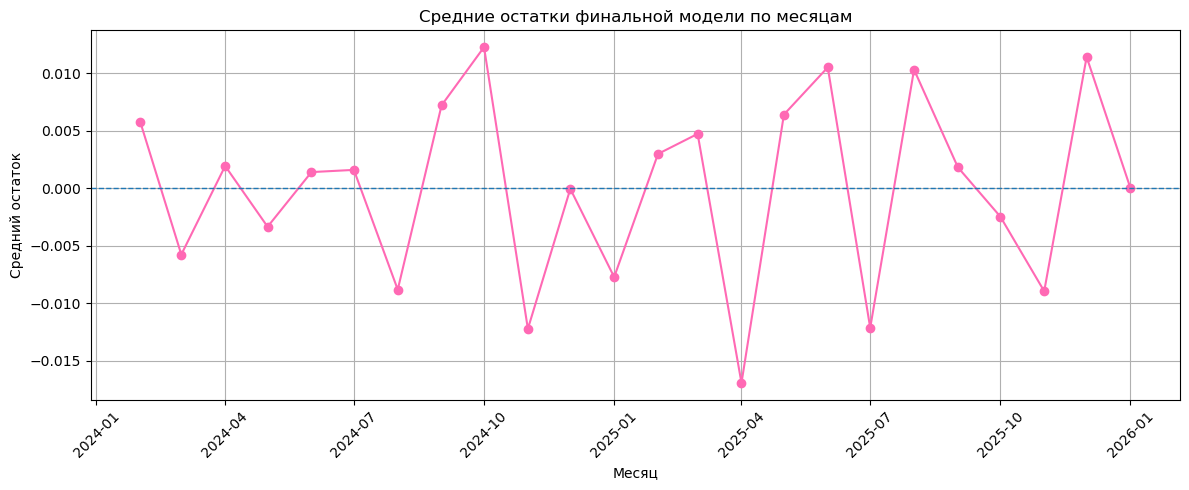

In [23]:
#остатки финальной модели во времени
dta_model = dta.loc[m3b.model.data.row_labels].copy()
dta_model["resid_m3b"] = m3b.resid

resid_by_month = (dta_model.groupby("month", observed=True)["resid_m3b"].mean().reset_index())

resid_by_month["month_date"] = pd.to_datetime(resid_by_month["month"].astype(str) + "-01")

plt.figure(figsize=(12, 5))
plt.plot(resid_by_month["month_date"], resid_by_month["resid_m3b"], marker="o", color='hotpink')
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Средние остатки финальной модели по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Средний остаток")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

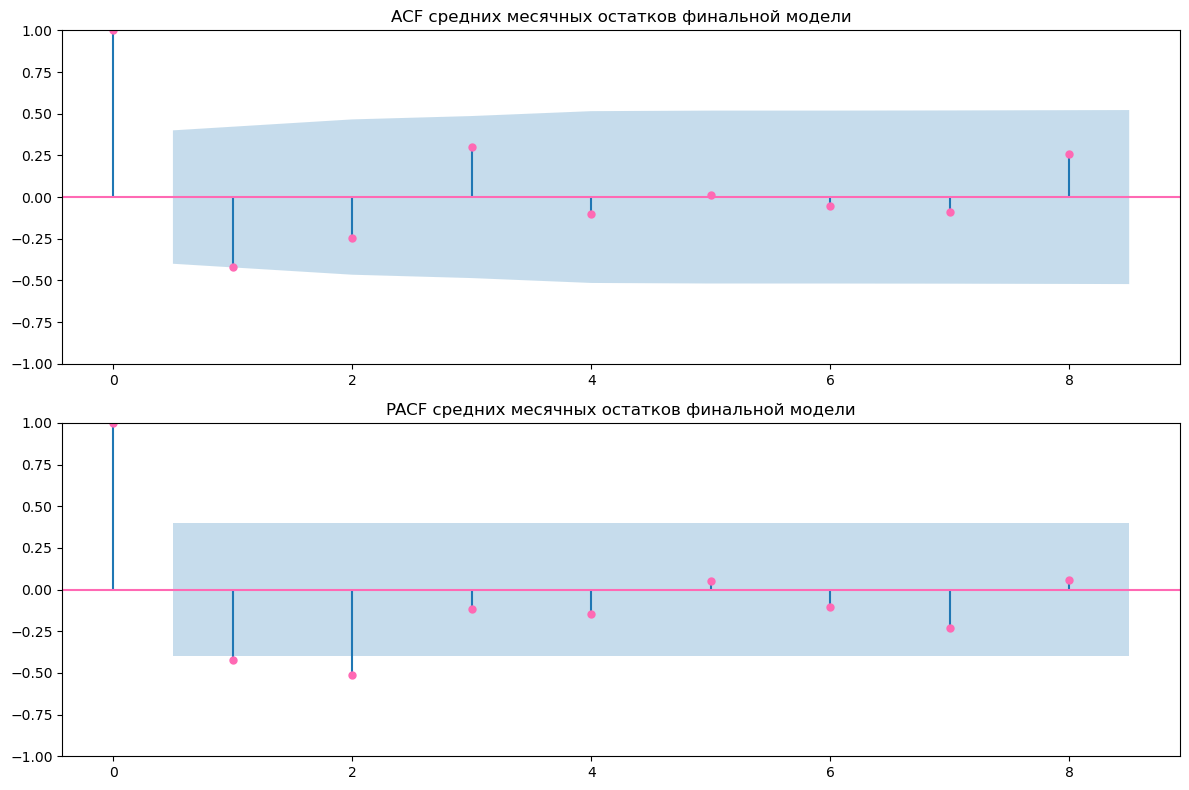

In [24]:
#acf и pacf остатков финальной модели
max_lags = min(8, len(resid_by_month) // 2 - 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(resid_by_month["resid_m3b"], lags=max_lags, ax=ax1, color='hotpink')
ax1.set_title("ACF средних месячных остатков финальной модели")

plot_pacf(resid_by_month["resid_m3b"], lags=max_lags, ax=ax2, method="ywm", color='hotpink')
ax2.set_title("PACF средних месячных остатков финальной модели")

plt.tight_layout()
plt.show()

In [25]:
#тест бреуша-годфри для средних месячных остатков
resid_bg = resid_by_month.copy()
resid_bg["resid_lag1"] = resid_bg["resid_m3b"].shift(1)
resid_bg = resid_bg.dropna(subset=["resid_m3b", "resid_lag1"])

resid_bg_model = statf.ols("resid_m3b ~ resid_lag1", data=resid_bg).fit()
resid_bg_result = dg.acorr_breusch_godfrey(resid_bg_model, nlags=min(3, len(resid_bg) // 3))

print("LM statistic:", resid_bg_result[0])
print("LM p-value:", resid_bg_result[1])
print("F statistic:", resid_bg_result[2])
print("F p-value:", resid_bg_result[3])

LM statistic: 7.158121905073315
LM p-value: 0.06702506584380998
F statistic: 2.711088368000636
F p-value: 0.07557057785131213
